<a href="https://colab.research.google.com/github/elajeans/IMAG2023/blob/main/oppgave3_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

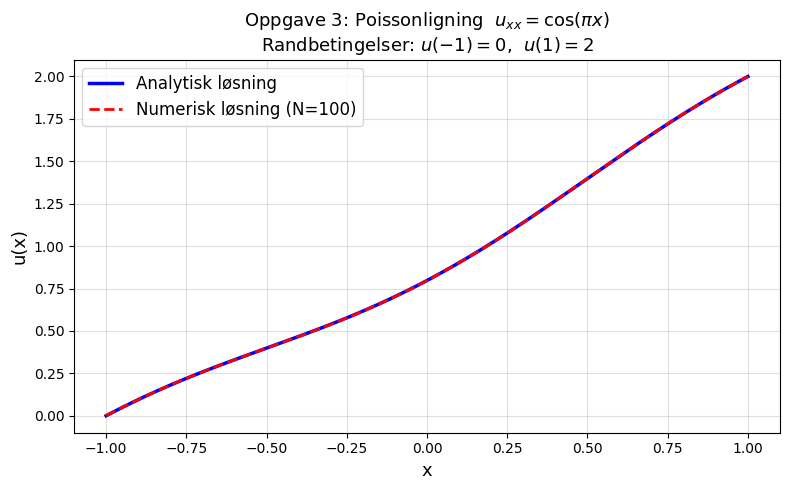

Maks feil: 6.53e-05


In [3]:
import numpy as np
import matplotlib.pyplot as plt


# OPPGAVE 3: Poissonligning 1D
# u_xx = cos(πx),  -1 <= x <= 1
# Randbetingelser: u(-1) = 0, u(1) = 2

# Integrer cos(πx) to ganger:
#   u'(x)  = sin(πx)/π + C1
#   u(x)   = -cos(πx)/π² + C1*x + C2
#
# Randbetingelser:
#   u(-1) = 1/π² - C1 + C2 = 0
#   u(1)  = 1/π² + C1 + C2 = 2
# => C1 = 1,  C2 = 1 - 1/π²

def u_analytisk(x):
    return -np.cos(np.pi * x) / np.pi**2 + x + 1 - 1/np.pi**2

# --- Numerisk løsning (finite differanser) ---
# (u_{i-1} - 2u_i + u_{i+1}) / h² = cos(πx_i)
N = 100
x_num = np.linspace(-1, 1, N + 2)
h = x_num[1] - x_num[0]

A = (np.diag(-2 * np.ones(N))
   + np.diag(np.ones(N-1), 1)
   + np.diag(np.ones(N-1), -1)) / h**2

x_inner = x_num[1:-1]
b = np.cos(np.pi * x_inner)
b[0]  -= 0 / h**2   # u(-1) = 0
b[-1] -= 2 / h**2   # u(1)  = 2

u_num = np.linalg.solve(A, b)
u_full = np.concatenate([[0], u_num, [2]])

# --- Plot ---
x_fine = np.linspace(-1, 1, 500)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_fine, u_analytisk(x_fine), 'b-', linewidth=2.5, label='Analytisk løsning')
ax.plot(x_num, u_full, 'r--', linewidth=2, label=f'Numerisk løsning (N={N})')
ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('u(x)', fontsize=13)
ax.set_title('Oppgave 3: Poissonligning  $u_{xx} = \\cos(\\pi x)$\n'
             'Randbetingelser: $u(-1)=0$,  $u(1)=2$', fontsize=13)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
print(f"Maks feil: {np.max(np.abs(u_full - u_analytisk(x_num))):.2e}")